In [1]:
import pandas as pd
import numpy as np
import os

# Find the CSV files
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'omega_class' in f:
 print(os.path.join(root, f))


/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/omega_class_moments.csv
/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/omega_class_moments_N1e6.csv
/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/omega_class_moments_fits_4points.csv


In [2]:
df1 = pd.read_csv('/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/omega_class_moments.csv')
df2 = pd.read_csv('/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/omega_class_moments_N1e6.csv')
fits = pd.read_csv('/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/omega_class_moments_fits_4points.csv')
print(df1)
print(df2)
print(fits)


 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451779 0.262002 
4 159.091605 14.413875 0.233885 0.212927 0.439947 0.273138 
5 181.308525 18.942436 0.450056 0.205916 0.432779 0.278650 
6 168.571130 20.716949 0.153646 0.246829 0.3

In [3]:
# Combine zeta data across all 4 N values
df_all = pd.concat([df1, df2], ignore_index=True)
zeta = df_all[df_all['L_function']=='zeta'].sort_values('N_terms').reset_index(drop=True)
print(zeta)


 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
2 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
3 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
4 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
5 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
6 zeta 1000000 884001.871616 500.0 21169.883300 264592.121329 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
2 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
3 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
4 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
5 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
6 453548.637660 137448.741642 6742.487684 0.000566 0.023948 0.299312 

 frac_3 frac_4 frac_geq5 
0 0.338769 0.024052 0.00

In [4]:
# df1 contained 3 entries that also got duplicated. Need to dedupe by N_terms
zeta = df_all[df_all['L_function']=='zeta'].drop_duplicates(subset='N_terms').sort_values('N_terms').reset_index(drop=True)
print(zeta[['N_terms','M_0','M_1','M_2','M_3','M_4','M_geq5']])


 N_terms M_0 M_1 M_2 M_3 M_4 \
0 10000 500.0 1965.747008 6483.537674 4759.568118 337.922395 
1 50000 500.0 3208.301641 21414.200073 24096.365734 3301.861669 
2 100000 500.0 4480.038022 37384.580762 48011.972434 8267.691145 
3 1000000 500.0 21169.883300 264592.121329 453548.637660 137448.741642 

 M_geq5 
0 2.835203 
1 35.047524 
2 130.950577 
3 6742.487684 


In [5]:
import numpy as np
import statsmodels.api as sm

N = zeta['N_terms'].values.astype(float)
logN = np.log(N)
loglogN = np.log(logN)
logloglogN = np.log(loglogN)

k_cols = ['M_0','M_1','M_2','M_3','M_4','M_geq5']

def fit_two_param(y, X_cols):
 """y is log M_k, X_cols includes intercept, loglogN, logloglogN"""
 X = sm.add_constant(np.column_stack(X_cols))
 model = sm.OLS(y, X).fit()
 return model

def fit_one_param(y, X_col):
 X = sm.add_constant(X_col)
 model = sm.OLS(y, X).fit()
 return model

results = []
for k in k_cols:
 Mk = zeta[k].values
 # Skip M_0 (constant 500) - log gives same value, can't fit meaningfully
 if np.allclose(Mk, Mk[0]):
 print(f"{k}: constant, skipping")
 continue
 y = np.log(Mk)
 # Two-param fit (4 points)
 m2_4 = fit_two_param(y, [loglogN, logloglogN])
 # One-param fit (4 points)
 m1_4 = fit_one_param(y, loglogN)
 # Two-param fit (first 3 points)
 m2_3 = fit_two_param(y[:3], [loglogN[:3], logloglogN[:3]])
 # One-param fit first 3
 m1_3 = fit_one_param(y[:3], loglogN[:3])
 
 a4, b4 = m2_4.params[1], m2_4.params[2]
 se_a4, se_b4 = m2_4.bse[1], m2_4.bse[2]
 a3, b3 = m2_3.params[1], m2_3.params[2]
 
 results.append({
 'k': k,
 'a_2p_4pts': a4, 'b_2p_4pts': b4, 'logC_2p_4pts': m2_4.params[0],
 'se_a_2p': se_a4, 'se_b_2p': se_b4,
 'R2_2p_4pts': m2_4.rsquared,
 'R2_1p_4pts': m1_4.rsquared,
 'a_1p_4pts': m1_4.params[1],
 'a_2p_3pts': a3, 'b_2p_3pts': b3,
 'a_1p_3pts': m1_3.params[1],
 'pct_change_a_2p': 100*(a3-a4)/abs(a4) if a4 != 0 else np.nan,
 'pct_change_b_2p': 100*(b3-b4)/abs(b4) if b4 != 0 else np.nan,
 'pct_change_a_1p': 100*(m1_3.params[1]-m1_4.params[1])/abs(m1_4.params[1]),
 'p_F_2p_vs_1p': None,
 })

res_df = pd.DataFrame(results)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
print(res_df.to_string(index=False))


M_0: constant, skipping
 k a_2p_4pts b_2p_4pts logC_2p_4pts se_a_2p se_b_2p R2_2p_4pts R2_1p_4pts a_1p_4pts a_2p_3pts b_2p_3pts a_1p_3pts pct_change_a_2p pct_change_b_2p pct_change_a_1p p_F_2p_vs_1p
 M_1 62.466693 -136.856914 -21.946539 1.909166 4.617935 0.999921 0.930312 5.909832 53.172454 -115.296206 3.561479 -14.878711 15.754197 -39.736376 None
 M_2 43.375580 -82.748822 -21.525482 0.530824 1.283971 0.999997 0.988786 9.179181 40.791410 -76.754083 7.764782 -5.957661 7.244500 -15.408772 None
 M_3 34.438728 -56.088214 -23.257879 0.457786 1.107304 0.999999 0.996549 11.259969 32.210123 -50.918314 10.300407 -6.471216 9.217445 -8.521894 None
 M_4 27.857893 -31.523000 -30.886309 0.045208 0.109350 1.000000 0.999370 14.830843 27.637812 -31.012456 14.293416 -0.790015 1.619591 -3.623710 None
M_geq5 80.469227 -148.055346 -59.539569 11.430739 27.648935 0.999716 0.991561 19.284554 136.116569 -277.145646 16.863160 69.153569 -87.190570 -12.556131 None


In [6]:
# Note: with 4 points and 2 predictors + intercept = 3 params, we have only 1 degree of freedom
# With 3 points and 3 params, df=0 - the fit is exact (R2 = 1) and we can't compute SE meaningfully
# Verify
for k in k_cols:
 Mk = zeta[k].values
 if np.allclose(Mk, Mk[0]): continue
 y = np.log(Mk)
 m2_3 = fit_two_param(y[:3], [loglogN[:3], logloglogN[:3]])
 print(k, "3pt R2:", m2_3.rsquared, "dof:", m2_3.df_resid)


M_1 3pt R2: 1.0 dof: 0.0
M_2 3pt R2: 1.0 dof: 0.0
M_3 3pt R2: 1.0 dof: 0.0
M_4 3pt R2: 1.0 dof: 0.0
M_geq5 3pt R2: 1.0 dof: 0.0


In [7]:
# So 3-pt 2-param fit is exact - not informative for assessing stability with R2,
# but parameter values can still be compared. Stability via parameter change %.

# F-test: compare 1-param vs 2-param using 4 points
from scipy import stats as sstats

for i, k in enumerate(k_cols):
 Mk = zeta[k].values
 if np.allclose(Mk, Mk[0]): continue
 y = np.log(Mk)
 m1 = fit_one_param(y, loglogN)
 m2 = fit_two_param(y, [loglogN, logloglogN])
 # F-test: (RSS1-RSS2)/1 / (RSS2/df2)
 RSS1 = np.sum(m1.resid**2)
 RSS2 = np.sum(m2.resid**2)
 df1, df2 = 1, m2.df_resid
 if RSS2 > 0 and df2 > 0:
 F = ((RSS1-RSS2)/1) / (RSS2/df2)
 p = 1 - sstats.f.cdf(F, 1, df2)
 else:
 F, p = np.inf, 0.0
 res_df.loc[res_df['k']==k, 'F_2p_vs_1p'] = F
 res_df.loc[res_df['k']==k, 'p_F_2p_vs_1p'] = p

print(res_df[['k','R2_1p_4pts','R2_2p_4pts','a_1p_4pts','a_2p_4pts','b_2p_4pts','F_2p_vs_1p','p_F_2p_vs_1p']].to_string(index=False))


 k R2_1p_4pts R2_2p_4pts a_1p_4pts a_2p_4pts b_2p_4pts F_2p_vs_1p p_F_2p_vs_1p
 M_1 0.930312 0.999921 5.909832 62.466693 -136.856914 878.289813 0.021473
 M_2 0.988786 0.999997 9.179181 43.375580 -82.748822 4153.493234 0.009877
 M_3 0.996549 0.999999 11.259969 34.438728 -56.088214 2565.720178 0.012567
 M_4 0.999370 1.000000 14.830843 27.857893 -31.523000 83103.608905 0.002208
M_geq5 0.991561 0.999716 19.284554 80.469227 -148.055346 28.674203 0.117533


In [8]:
# Stability comparison
print("Stability comparison: percent change in fitted exponents from 4-pt to 3-pt fit")
print(res_df[['k','a_1p_4pts','a_1p_3pts','pct_change_a_1p','a_2p_4pts','a_2p_3pts','pct_change_a_2p','b_2p_4pts','b_2p_3pts','pct_change_b_2p']].to_string(index=False))


Stability comparison: percent change in fitted exponents from 4-pt to 3-pt fit
 k a_1p_4pts a_1p_3pts pct_change_a_1p a_2p_4pts a_2p_3pts pct_change_a_2p b_2p_4pts b_2p_3pts pct_change_b_2p
 M_1 5.909832 3.561479 -39.736376 62.466693 53.172454 -14.878711 -136.856914 -115.296206 15.754197
 M_2 9.179181 7.764782 -15.408772 43.375580 40.791410 -5.957661 -82.748822 -76.754083 7.244500
 M_3 11.259969 10.300407 -8.521894 34.438728 32.210123 -6.471216 -56.088214 -50.918314 9.217445
 M_4 14.830843 14.293416 -3.623710 27.857893 27.637812 -0.790015 -31.523000 -31.012456 1.619591
M_geq5 19.284554 16.863160 -12.556131 80.469227 136.116569 69.153569 -148.055346 -277.145646 -87.190570


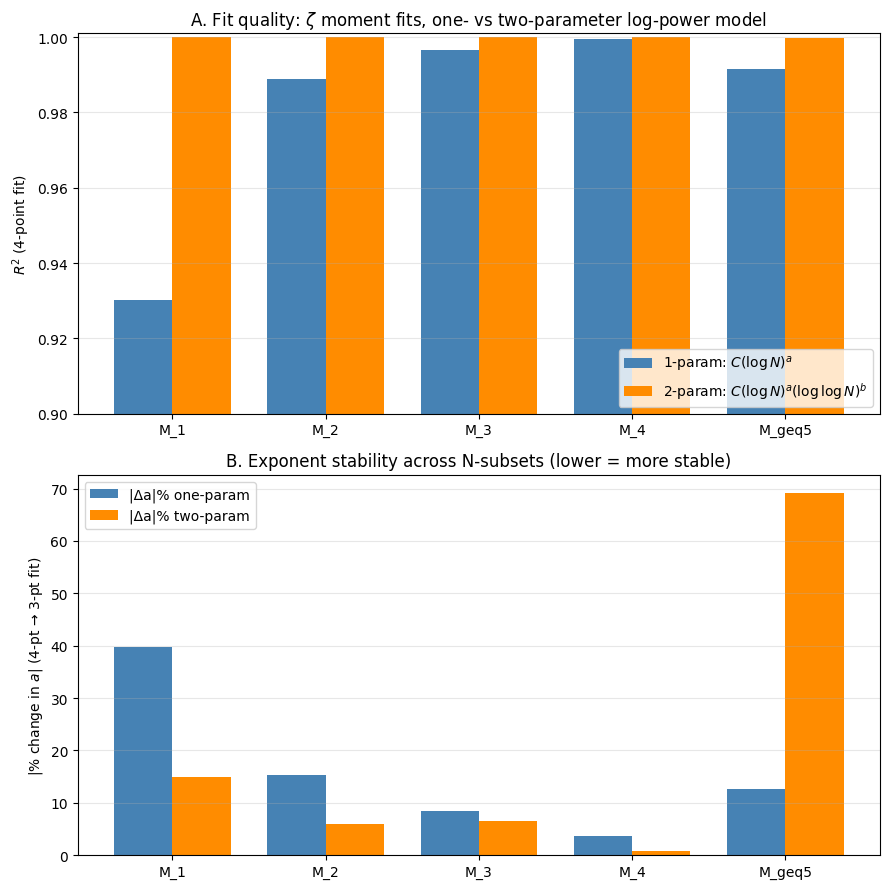

Saved figure.


In [9]:
# Save full results
res_df.to_csv('/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/zeta_two_param_loglog_fits.csv', index=False)

# Create summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: R2 comparison 
ax = axes[0]
ks = res_df['k'].tolist()
x = np.arange(len(ks))
w = 0.38
ax.bar(x - w/2, res_df['R2_1p_4pts'], w, label='1-param: $C(\\log N)^a$', color='steelblue')
ax.bar(x + w/2, res_df['R2_2p_4pts'], w, label='2-param: $C(\\log N)^a(\\log\\log N)^b$', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.set_ylim(0.9, 1.001)
ax.set_ylabel('$R^2$ (4-point fit)')
ax.set_title('A. Fit quality: $\\zeta$ moment fits, one- vs two-parameter log-power model')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Panel B: stability — % change of fitted exponent a between 4-pt and 3-pt fits
ax = axes[1]
ax.bar(x - w/2, np.abs(res_df['pct_change_a_1p']), w, label='|Δa|% one-param', color='steelblue')
ax.bar(x + w/2, np.abs(res_df['pct_change_a_2p']), w, label='|Δa|% two-param', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.set_ylabel('|% change in $a$| (4-pt → 3-pt fit)')
ax.set_title('B. Exponent stability across N-subsets (lower = more stable)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/workspace/6cfdcf13-33c4-4b1d-a91f-618baec68e93/zeta_two_param_fit_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")
